<a href="https://colab.research.google.com/github/SuperGlent/Notebooks/blob/main/SGD_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this notebook I will consider a few algorithms which are the main for ambigous part of ML consisting Neural networks! SGD and SAG from scratch. Let's begin!

In [15]:
#upgrade all nessacary packages
!pip install --upgrade pip

In [16]:
#import packages
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import math
import pandas as pd
import os
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

In [17]:
#download the dataset, there I will use some simple dataset for binary classification
import kagglehub

path = kagglehub.dataset_download("nimapourmoradi/raisin-binary-classification")
print(f"Path to file: {path}")


Using Colab cache for faster access to the 'raisin-binary-classification' dataset.
Path to file: /kaggle/input/raisin-binary-classification


In [18]:
print(os.listdir(path))

['Raisin_Dataset.xlsx', 'Raisin_Dataset.csv']


In [19]:
#take a look on the data
path = path + "/Raisin_Dataset.csv"
data = pd.read_csv(path)
print(data.head())

    Area  MajorAxisLength  MinorAxisLength  Eccentricity  ConvexArea  \
0  87524       442.246011       253.291155      0.819738       90546   
1  75166       406.690687       243.032436      0.801805       78789   
2  90856       442.267048       266.328318      0.798354       93717   
3  45928       286.540559       208.760042      0.684989       47336   
4  79408       352.190770       290.827533      0.564011       81463   

     Extent  Perimeter    Class  
0  0.758651   1184.040  Kecimen  
1  0.684130   1121.786  Kecimen  
2  0.637613   1208.575  Kecimen  
3  0.699599    844.162  Kecimen  
4  0.792772   1073.251  Kecimen  


In [20]:
data.describe()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,87804.127778,430.929950,254.488133,0.781542,91186.090000,0.699508,1165.906636
std,39002.111390,116.035121,49.988902,0.090318,40769.290132,0.053468,273.764315
min,25387.000000,225.629541,143.710872,0.348730,26139.000000,0.379856,619.074000
25%,59348.000000,345.442898,219.111126,0.741766,61513.250000,0.670869,966.410750
50%,78902.000000,407.803951,247.848409,0.798846,81651.000000,0.707367,1119.509000
75%,105028.250000,494.187014,279.888575,0.842571,108375.750000,0.734991,1308.389750
max,235047.000000,997.291941,492.275279,0.962124,278217.000000,0.835455,2697.753000


Count of values which are none is: 0


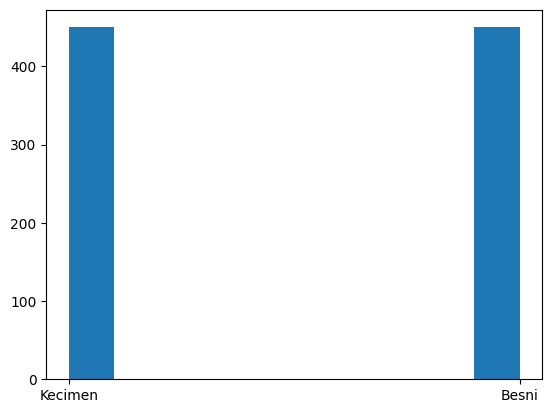

In [21]:
#download dataset
X_train = data.drop("Class", axis=1)
Y_train = data["Class"]
isnullsum = Y_train.isnull().sum()
plt.hist(Y_train)
print(f"Count of values which are none is: {isnullsum}")

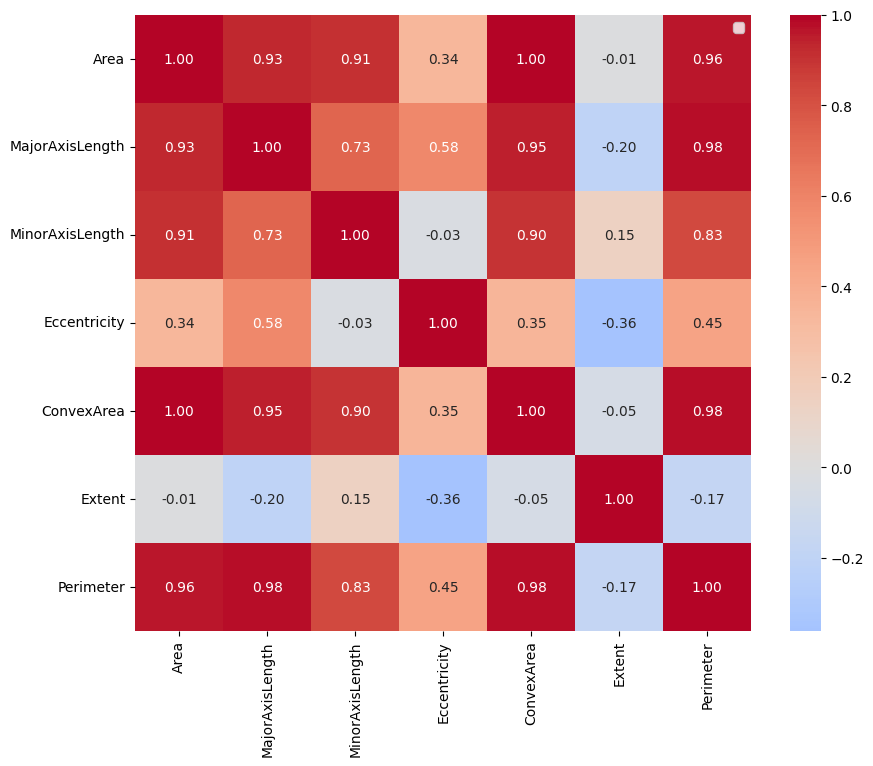

In [22]:
import seaborn as sb

matrix = np.array(X_train)
corrcoef = X_train.corr(method="pearson")

plt.figure(figsize=(10, 8))
sb.heatmap(
    corrcoef,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.legend("Correlation matrix between feautures")
plt.show()

Great! Now we have data and we also know that classes destribution is equal. We just have to normalize data to to avoid uneven gradient descent. Also we can see that our classes features have strong lineA\ar correlation, even dependency. But in our case it's not such a problem.

In [23]:
Y_train = Y_train.replace({"Kecimen": -1, "Besni": 1})
print(Y_train)

0     -1
1     -1
2     -1
3     -1
4     -1
      ..
895    1
896    1
897    1
898    1
899    1
Name: Class, Length: 900, dtype: int64


/tmp/ipykernel_12723/3526082781.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Y_train = Y_train.replace({"Kecimen": -1, "Besni": 1})


In [24]:
#Standartize data with sklearn StandartScaler, by formula (x_i - x_mean)/x_std. We could make it ourselfs with pandas)
scaler = StandardScaler()
col = X_train.columns
X_train_scaled = scaler.fit_transform(X_train.copy())
pd.DataFrame(X_train_scaled, columns=col).describe()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter
count,9.000000e+02,900.000000,9.000000e+02,9.000000e+02,9.000000e+02,9.000000e+02,9.000000e+02
mean,1.894781e-16,0.000000,-8.210716e-16,6.947529e-16,6.315935e-17,1.436875e-15,-6.315935e-17
std,1.000556e+00,1.000556,1.000556e+00,1.000556e+00,1.000556e+00,1.000556e+00,1.000556e+00
min,-1.601242e+00,-1.770279,-2.217269e+00,-4.794739e+00,-1.596379e+00,-5.981678e+00,-1.998568e+00
25%,-7.300105e-01,-0.737144,-7.080907e-01,-4.406412e-01,-7.282280e-01,-5.359214e-01,-7.291192e-01
50%,-2.283742e-01,-0.199413,-1.328978e-01,1.916942e-01,-2.340093e-01,1.470669e-01,-1.695745e-01
75%,4.418658e-01,0.545458,5.084041e-01,6.760837e-01,4.218670e-01,6.640063e-01,5.207484e-01
max,3.777353e+00,4.883667,4.759444e+00,2.000508e+00,4.590095e+00,2.543983e+00,5.598604e+00


In [25]:
#Splitting dataset to train and test to evaluate it and compare it with the same sklearn model
X_train_sk, X_test_sk, Y_train_sk, Y_test_sk = train_test_split(X_train_scaled, Y_train, random_state=30)

Let me define the basics, then we will move on to the implementation of algorithms. So the main reason why gradient algorithms are so usefull, is that we can iteratively improove our algorithm instaed of finding just one inverse matrix for our features. As an example we could find our solution for square loss function as Sum of dot products of input i and output i multiplyed by inverse matrix of input * inputtransposed. But when we have a lot of parametrs we can't rely on this method because the inverse matrix could even not exists or to be very difficult to calculate. So we will define gradient of our loss function (I will consider hinge like in SVM) and change weigth as w(t+1) = w(t) - lam * grad Q(w(t)). For convergence of our algoritm, the empirical gradient should on average form an acute angle with the real gradient by all objects in our dataset. So we will take only one object for iteration (or group of objects, known as minibatch) and improove our algorithm by this calculation of gradient.


In [26]:
def hinge_loss(ys, labs) -> float:
  return np.maximum(0, 1 - ys * labs)

In [27]:
def init_weigth() -> np.ndarray: #shape = n_features or 7
  return np.random.uniform(-1, 1, n_features)

In [28]:
epochs = 1000 #how many times we will train by the same data*
lam = 0.002
mu = 0.001
batch_size = 50

X = X_train_sk
y = Y_train_sk.to_numpy()

n_samples, n_features = X.shape
print(X.shape)
print(y.shape)
#weigth initializing
w_hinge = init_weigth()
Q = 1

(675, 7)
(675,)


In [29]:
def get_batch():
  idx = np.random.randint(0, n_samples, batch_size)
  return X[idx], y[idx]

In [30]:
Qs = []

for epoch in range(epochs):
  xs, ys_true = get_batch()
  # predictions and margins
  ys_pred = xs @ w_hinge
  margins = ys_true * ys_pred

  # loss
  losses = hinge_loss(ys_pred, ys_true)
  loss = losses.mean()

  grad = np.zeros_like(w_hinge)
  for x_i, y_i, m in zip(xs, ys_true, margins):
    if m > 0:
      grad_i = grad + (-y_i * x_i)
      grad = lam * grad + (1- lam) * grad_i

  grad /= batch_size
  # SGD step + L2
  w_hinge = w_hinge - mu * (grad + 0.5 * w_hinge)

  # EMA
  Q = lam * Q + (1 - lam) * loss
  Qs.append(loss)

  if epoch % 50 == 0:
    print(f"epoch {epoch}: Q = {Q:.6f}")

  if loss <= 0.3:
    break

epoch 0: Q = 0.549836
epoch 50: Q = 0.897749
epoch 100: Q = 0.499311
epoch 150: Q = 0.984536
epoch 200: Q = 0.525951
epoch 250: Q = 0.489859
epoch 300: Q = 0.729500
epoch 350: Q = 0.817338


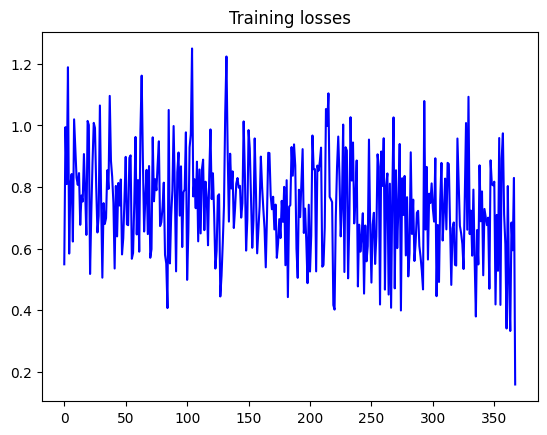

In [31]:
plt.plot(Qs, c="blue")
#plt.plot(Qs_exp, c="red")
plt.title("Training losses")
plt.show()

In [32]:
#Let's see how sklearn model works, pretty good accuracy on the test dataset.
cls = make_pipeline(SGDClassifier(max_iter=1000))
cls.fit(X_train_sk, Y_train_sk)
score = cls.score(X_test_sk, Y_test_sk)
print(score)

0.8488888888888889


In [33]:
#lets evaluate our model
X_test = X_test_sk
y_test = Y_test_sk.to_numpy()

y_score = X_test @ w_hinge
y_pred = np.sign(y_score)

accuracy = np.mean(y_pred == y_test)
print("Your model accuracy:", accuracy)

Your model accuracy: 0.7466666666666667


Such a good result! You could have another results, but it still should be pretty good, !< 70. Thank's for your attention, small algorithm wich standing fundamental for a lot of learning methods!